# Step 1: Data Acquisition & Wrangling

In [1]:
!pip install tensorflow keras scikit-learn pillow matplotlib pandas numpy scipy -q

In [2]:
import os
import shutil
import zipfile
from sklearn.model_selection import train_test_split
from google.colab import userdata

# Step 1: Configure Kaggle API using secrets
print("Configuring Kaggle API...")
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Step 2: Download Kaggle dataset
print("\nDownloading Kaggle fruit ripeness dataset...")
dataset_slug = "leftin/fruit-ripeness-unripe-ripe-and-rotten"
os.system(f"kaggle datasets download -d {dataset_slug} -q")

# Step 3: Extract and organize
dataset_zip = "fruit-ripeness-unripe-ripe-and-rotten.zip"
extract_path = "fruit_ripeness_raw"

if os.path.exists(dataset_zip):
    print(f"Extracting {dataset_zip}...")
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted to {extract_path}/")
    os.remove(dataset_zip)

# Robust check for class folders
# We look for the folder that actually contains subfolders with images
actual_base = None
for root, dirs, files in os.walk(extract_path):
    # If a folder has subfolders and those subfolders contain images, it's our base
    if dirs:
        first_sub = os.path.join(root, dirs[0])
        if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(first_sub) if os.path.isfile(os.path.join(first_sub, f))):
            actual_base = root
            break

train_path = os.path.join(extract_path, "train")
valid_path = os.path.join(extract_path, "valid")
test_path = os.path.join(extract_path, "test")

if actual_base:
    print(f"Found data source at: {actual_base}")
    raw_classes = sorted([d for d in os.listdir(actual_base) if os.path.isdir(os.path.join(actual_base, d))])

    # Prepare split directories
    for p in [train_path, valid_path, test_path]:
        if os.path.exists(p): shutil.rmtree(p)
        os.makedirs(p, exist_ok=True)

    for class_name in raw_classes:
        class_dir = os.path.join(actual_base, class_name)
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        if not images:
            continue

        train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)
        valid_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

        for split, split_imgs in [('train', train_imgs), ('valid', valid_imgs), ('test', test_imgs)]:
            dest_dir = os.path.join(extract_path, split, class_name)
            os.makedirs(dest_dir, exist_ok=True)
            for img in split_imgs:
                shutil.copy2(os.path.join(class_dir, img), os.path.join(dest_dir, img))

        print(f"  {class_name}: {len(train_imgs)} train, {len(valid_imgs)} valid, {len(test_imgs)} test")

    print(f"\n--- Success! Data organized at: {extract_path} ---")
else:
    print("Error: Could not locate class folders within the extracted ZIP.")

Configuring Kaggle API...

Extracting fruit-ripeness-unripe-ripe-and-rotten.zip...
Extracted to fruit_ripeness_raw/
Found data source at: fruit_ripeness_raw/fruit_ripeness_dataset/archive (1)/dataset/dataset/test
  freshapples: 316 train, 39 valid, 40 test
  freshbanana: 304 train, 38 valid, 39 test
  freshoranges: 310 train, 39 valid, 39 test
  rottenapples: 480 train, 60 valid, 61 test
  rottenbanana: 424 train, 53 valid, 53 test
  rottenoranges: 322 train, 40 valid, 41 test
  unripe apple: 296 train, 37 valid, 38 test
  unripe banana: 320 train, 40 valid, 40 test
  unripe orange: 216 train, 27 valid, 27 test

--- Success! Data organized at: fruit_ripeness_raw ---


In [3]:
import os
import shutil

extract_path = "fruit_ripeness_raw"
splits = ['train', 'valid', 'test']

# 1. Define the groupings
fresh_classes = ['freshapples', 'freshbanana', 'freshoranges']
rotten_classes = ['rottenapples', 'rottenbanana', 'rottenoranges']
unripe_classes = ['unripe apple', 'unripe banana', 'unripe orange']

print("Restructuring dataset into binary categories: Fresh vs Rotten...")

for split in splits:
    split_dir = os.path.join(extract_path, split)
    if not os.path.exists(split_dir):
        continue

    # Create new binary target folders
    binary_fresh_dir = os.path.join(split_dir, 'Fresh')
    binary_rotten_dir = os.path.join(split_dir, 'Rotten')
    os.makedirs(binary_fresh_dir, exist_ok=True)
    os.makedirs(binary_rotten_dir, exist_ok=True)

    # Move 'fresh' fruit images
    for f_class in fresh_classes:
        src = os.path.join(split_dir, f_class)
        if os.path.exists(src):
            for file in os.listdir(src):
                shutil.move(os.path.join(src, file), os.path.join(binary_fresh_dir, file))
            shutil.rmtree(src)

    # Move 'rotten' fruit images
    for r_class in rotten_classes:
        src = os.path.join(split_dir, r_class)
        if os.path.exists(src):
            for file in os.listdir(src):
                shutil.move(os.path.join(src, file), os.path.join(binary_rotten_dir, file))
            shutil.rmtree(src)

    # Discard 'unripe' images to reduce ambiguity
    for u_class in unripe_classes:
        src = os.path.join(split_dir, u_class)
        if os.path.exists(src):
            shutil.rmtree(src)

print("Success! Dataset successfully collapsed into Binary (Fresh vs Rotten).")
print("Please re-run the next cell (Load Data) to update the model targets.")

Restructuring dataset into binary categories: Fresh vs Rotten...
Success! Dataset successfully collapsed into Binary (Fresh vs Rotten).
Please re-run the next cell (Load Data) to update the model targets.


In [4]:
import tensorflow as tf
import numpy as np
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Dynamically find the classes from the Roboflow directory structure
folder_classes = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Detected classes: {folder_classes}")

# Load Training Data (RGB for fruit classification)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=folder_classes,
    label_mode="categorical",
)

# Load Validation Data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=folder_classes,
    label_mode="categorical",
)

# Load Testing Data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=folder_classes,
    label_mode="categorical",
)

class_names = train_dataset.class_names
num_classes = len(class_names)

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print(f"\nSuccess! Classes: {class_names}")

# Calculate class weights to reduce class imbalance bias
class_counts = {}
for c in folder_classes:
    folder_path = os.path.join(train_path, c)
    if os.path.exists(folder_path):
        class_counts[c] = len(os.listdir(folder_path))
    else:
        class_counts[c] = 0

total_images = sum(class_counts.values())
class_weights = {}

for i, class_name in enumerate(class_names):
    count = class_counts[class_name]
    weight = (1 / count) * (total_images / float(num_classes)) if count > 0 else 1.0
    class_weights[i] = weight

print("\nCalculated class weights:")
for i, name in enumerate(class_names):
    print(f"{name} (index {i}): {class_weights[i]:.2f}")

Detected classes: ['Fresh', 'Rotten']
Found 2156 files belonging to 2 classes.
Found 269 files belonging to 2 classes.
Found 273 files belonging to 2 classes.

Success! Classes: ['Fresh', 'Rotten']

Calculated class weights:
Fresh (index 0): 1.16
Rotten (index 1): 0.88


In [5]:
import os
import hashlib
import numpy as np
from PIL import Image

print("--- DUPLICATE CHECK (TRAIN vs VALID vs TEST) ---")
print("This checks exact duplicates (MD5) and likely near-duplicates (aHash).")

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")


def iter_image_files(root_dir):
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith(IMAGE_EXTS):
                yield os.path.join(dirpath, name)


def file_md5(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            data = f.read(chunk_size)
            if not data:
                break
            h.update(data)
    return h.hexdigest()


def ahash(path, size=16):
    img = Image.open(path).convert("L").resize((size, size))
    arr = np.array(img)
    avg = arr.mean()
    bits = (arr >= avg).astype(np.uint8).flatten()
    return "".join(bits.astype(str))


def build_index(paths, hasher):
    index = {}
    for p in paths:
        h = hasher(p)
        index.setdefault(h, []).append(p)
    return index


def overlap(idx_a, idx_b):
    common = set(idx_a.keys()) & set(idx_b.keys())
    return {k: (idx_a[k], idx_b[k]) for k in common}


def print_overlap(label, dup_map, limit=3):
    print(f"{label}: {len(dup_map)} matches")
    shown = 0
    for _, (left, right) in dup_map.items():
        print("  L:", left[0])
        print("  R:", right[0])
        shown += 1
        if shown >= limit:
            break


train_files = list(iter_image_files(train_path))
valid_files = list(iter_image_files(valid_path))
test_files = list(iter_image_files(test_path))

print(f"Train files: {len(train_files)}")
print(f"Valid files: {len(valid_files)}")
print(f"Test files:  {len(test_files)}")

# Exact duplicate check (byte-for-byte)
md5_train = build_index(train_files, file_md5)
md5_valid = build_index(valid_files, file_md5)
md5_test = build_index(test_files, file_md5)

exact_tv = overlap(md5_train, md5_valid)
exact_tt = overlap(md5_train, md5_test)
exact_vt = overlap(md5_valid, md5_test)

print("\nExact duplicates (MD5):")
print_overlap("Train vs Valid", exact_tv)
print_overlap("Train vs Test", exact_tt)
print_overlap("Valid vs Test", exact_vt)

# Near-duplicate check (aHash). Note: aHash can have false positives.
ah_train = build_index(train_files, ahash)
ah_valid = build_index(valid_files, ahash)
ah_test = build_index(test_files, ahash)

near_tv = overlap(ah_train, ah_valid)
near_tt = overlap(ah_train, ah_test)
near_vt = overlap(ah_valid, ah_test)

print("\nLikely near-duplicates (aHash, may include false positives):")
print_overlap("Train vs Valid", near_tv)
print_overlap("Train vs Test", near_tt)
print_overlap("Valid vs Test", near_vt)

--- DUPLICATE CHECK (TRAIN vs VALID vs TEST) ---
This checks exact duplicates (MD5) and likely near-duplicates (aHash).
Train files: 2156
Valid files: 269
Test files:  273

Exact duplicates (MD5):
Train vs Valid: 0 matches
Train vs Test: 0 matches
Valid vs Test: 0 matches

Likely near-duplicates (aHash, may include false positives):
Train vs Valid: 8 matches
  L: fruit_ripeness_raw/train/Fresh/Screen Shot 2018-06-12 at 9.39.33 PM.png
  R: fruit_ripeness_raw/valid/Fresh/saltandpepper_Screen Shot 2018-06-12 at 9.39.33 PM.png
  L: fruit_ripeness_raw/train/Rotten/saltandpepper_Screen Shot 2018-06-12 at 11.26.36 PM.png
  R: fruit_ripeness_raw/valid/Rotten/Screen Shot 2018-06-12 at 11.26.36 PM.png
  L: fruit_ripeness_raw/train/Rotten/saltandpepper_Screen Shot 2018-06-12 at 8.54.48 PM.png
  R: fruit_ripeness_raw/valid/Rotten/Screen Shot 2018-06-12 at 8.54.48 PM.png
Train vs Test: 10 matches
  L: fruit_ripeness_raw/train/Rotten/Screen Shot 2018-06-08 at 2.51.28 PM.png
  R: fruit_ripeness_raw/t

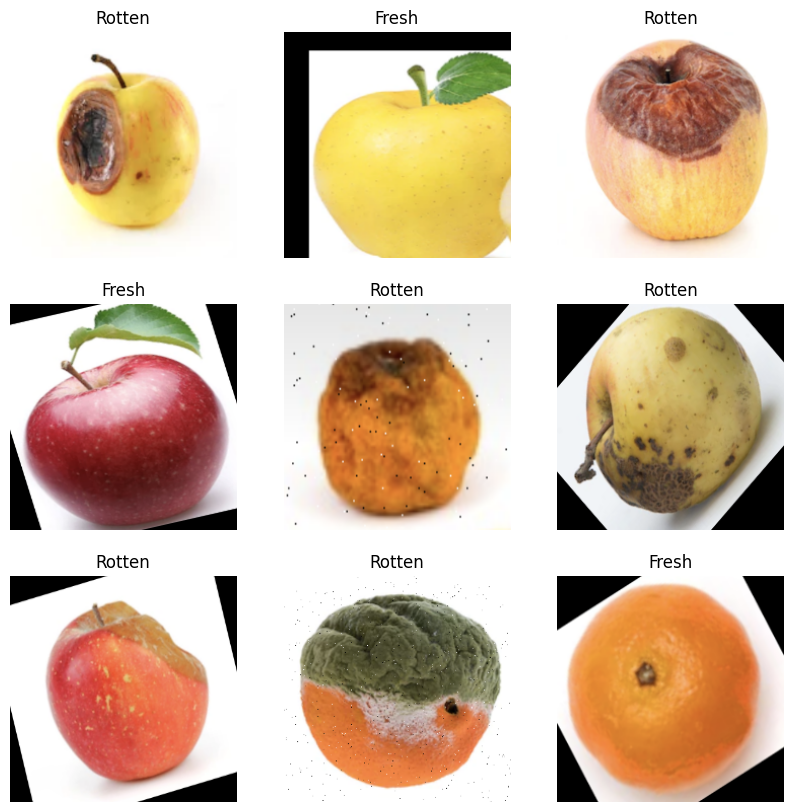

In [6]:
import matplotlib.pyplot as plt
import tensorflow as tf

plt.figure(figsize=(10, 10))

# take one batch of images and their labels
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        img_to_show = images[i].numpy().astype("uint8")
        if img_to_show.shape[-1] == 1:
            plt.imshow(img_to_show.squeeze(), cmap="gray")
        else:
            plt.imshow(img_to_show)

        # translate the multiple-choice array back into a single number
        class_index = tf.argmax(labels[i]).numpy()

        # Use that number to get the correct word from our class names
        plt.title(class_names[class_index])

        plt.axis("off")

plt.show()

# Step 2: Define the Custom CNN


### Model 1

In [7]:
from tensorflow.keras import layers, models

# Input is RGB for fruit images
input_shape = (224, 224, 3)

# --- Augmentation to avoid overfitting ---
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.1),
  layers.GaussianNoise(0.1),
])

model_custom = models.Sequential([
    data_augmentation,
    layers.Rescaling(1.0 / 255, input_shape=input_shape),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

model_custom.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Create a fake RGB image (all zeros) to prime the model
dummy_input = tf.zeros((1, 224, 224, 3))
model_custom(dummy_input)

# Show summary
model_custom.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 2)                 │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Step 3: Define the MobileNetV2

### Model 2

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

# MobileNetV2 model for RGB fruit images

data_augmentation_mobile = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.1),
  layers.GaussianNoise(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Keep feature extractor frozen to reduce overfitting
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation_mobile(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax", kernel_regularizer=regularizers.l2(1e-4))(x)

model_mobilenet = tf.keras.Model(inputs=inputs, outputs=outputs)
model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 4: The Training

In [10]:
# Compile Model 1 (Custom)
model_custom.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Compile Model 2 (MobileNetV2)
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Both models are compiled and ready to learn!")

Both models are compiled and ready to learn!


In [11]:
EPOCHS = 15

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
]

print("--- Training Model 1: Custom CNN ---")
history_custom = model_custom.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
)

print("\n--- Training Model 2: MobileNetV2 ---")
history_mobilenet = model_mobilenet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
)

--- Training Model 1: Custom CNN ---
Epoch 1/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.6183 - loss: 0.6407 - val_accuracy: 0.7100 - val_loss: 0.5358 - learning_rate: 1.0000e-04
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.7750 - loss: 0.4809 - val_accuracy: 0.8550 - val_loss: 0.3765 - learning_rate: 1.0000e-04
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.8479 - loss: 0.3494 - val_accuracy: 0.8587 - val_loss: 0.3298 - learning_rate: 1.0000e-04
Epoch 4/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.8581 - loss: 0.3365 - val_accuracy: 0.8030 - val_loss: 0.3904 - learning_rate: 1.0000e-04
Epoch 5/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.8748 - loss: 0.2925 - val_accuracy: 0.8848 - val_loss: 0.3126 - learning_rate: 1.0000e-04
Epoch 6/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.8910 - loss: 0.2616 - val_accuracy: 0.8401 - val_loss: 0.3650 - learning_rate: 1.0000e-04
Epoch 7/15
68/68 ━━━━━━━━

# Step 5: Visualization

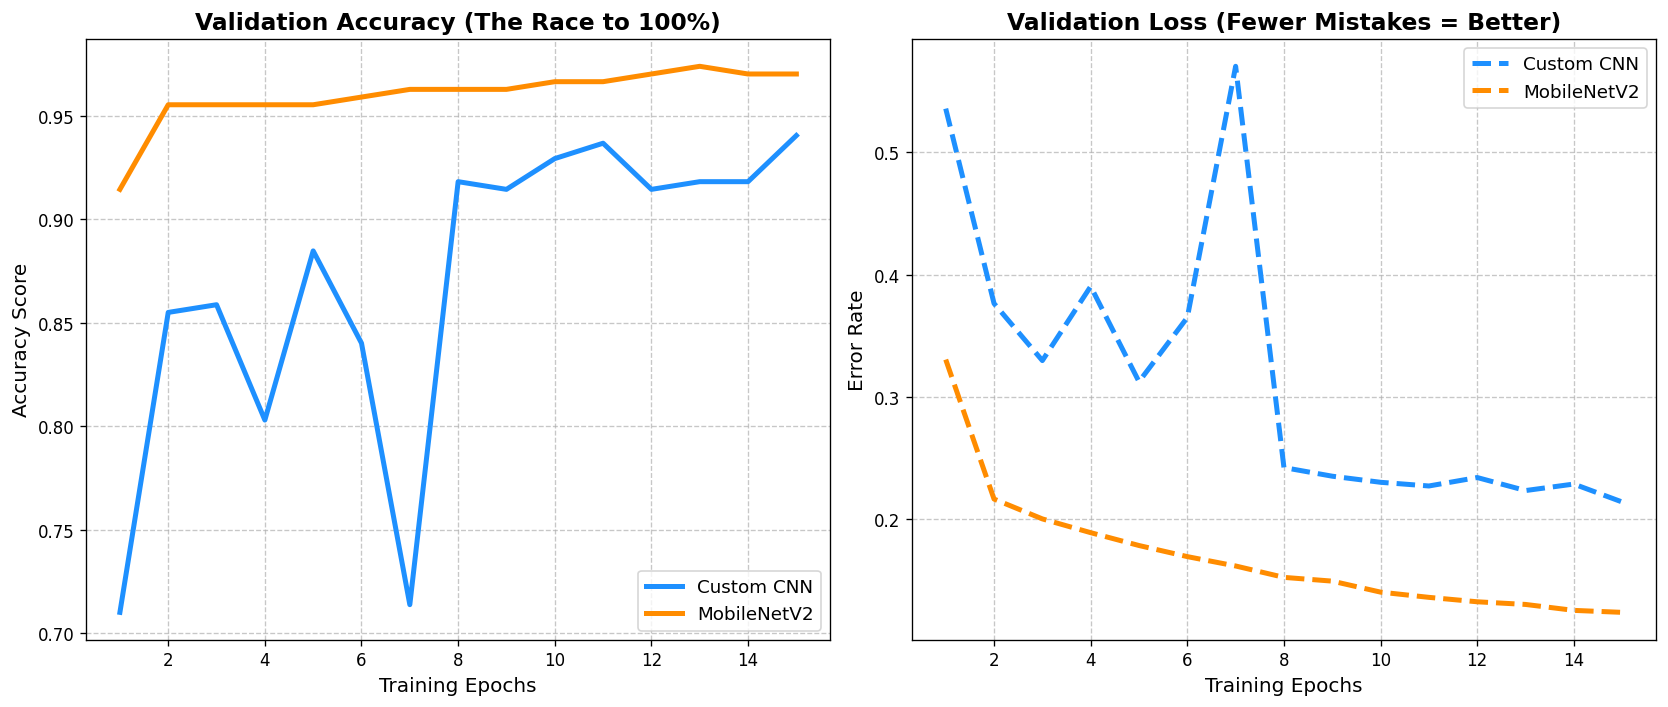

In [12]:
import matplotlib.pyplot as plt

def plot_history_upgraded(history_custom, history_mobilenet):
    # Extract Accuracy
    val_acc_custom = history_custom.history['val_accuracy']
    val_acc_mobile = history_mobilenet.history['val_accuracy']

    # Extract Loss (Error)
    val_loss_custom = history_custom.history['val_loss']
    val_loss_mobile = history_mobilenet.history['val_loss']

    # THE FIX: Create independent X-axis ranges for each model
    epochs_range_custom = range(1, len(val_acc_custom) + 1)
    epochs_range_mobile = range(1, len(val_acc_mobile) + 1)

    # Create a wide, high-resolution canvas
    plt.figure(figsize=(14, 6), dpi=120)

    # Graph 1: Validation Accuracy (higher is better)
    plt.subplot(1, 2, 1)
    # Use the specific ranges here
    plt.plot(epochs_range_custom, val_acc_custom, label='Custom CNN', color='dodgerblue', linewidth=3)
    plt.plot(epochs_range_mobile, val_acc_mobile, label='MobileNetV2', color='darkorange', linewidth=3)
    plt.title('Validation Accuracy (The Race to 100%)', fontsize=14, fontweight='bold')
    plt.xlabel('Training Epochs', fontsize=12)
    plt.ylabel('Accuracy Score', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Graph 2: Validation Loss (lower is better)
    plt.subplot(1, 2, 2)
    # And use the specific ranges here too
    plt.plot(epochs_range_custom, val_loss_custom, label='Custom CNN', color='dodgerblue', linewidth=3, linestyle='--')
    plt.plot(epochs_range_mobile, val_loss_mobile, label='MobileNetV2', color='darkorange', linewidth=3, linestyle='--')
    plt.title('Validation Loss (Fewer Mistakes = Better)', fontsize=14, fontweight='bold')
    plt.xlabel('Training Epochs', fontsize=12)
    plt.ylabel('Error Rate', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_history_upgraded(history_custom, history_mobilenet)

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("🔍 Analyzing Testing Data (Unseen Data)...")

y_true = []
y_pred_classes = []

# Loop through the unseen testing data
for images, labels in test_dataset:
    # 1. Ask the Custom Model to guess this specific batch
    # Change 'model_custom' to 'model_mobilenet' if you want to test the other one
    preds = model_custom.predict(images, verbose=0)

    # 2. Translate guesses into simple integers
    y_pred_classes.extend(np.argmax(preds, axis=1))

    # 3. Translate the true labels from One-Hot into simple integers
    y_true.extend(np.argmax(labels, axis=1))

print("\n✅ Confusion Matrix (Custom CNN):")
print(confusion_matrix(y_true, y_pred_classes))

print("\n📊 Classification Report (Custom CNN):")
# Now that we use Roboflow, we dynamically pass whatever labels they provided:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

🔍 Analyzing Testing Data (Unseen Data)...

✅ Confusion Matrix (Custom CNN):
[[108  10]
 [  9 146]]

📊 Classification Report (Custom CNN):
              precision    recall  f1-score   support

       Fresh       0.92      0.92      0.92       118
      Rotten       0.94      0.94      0.94       155

    accuracy                           0.93       273
   macro avg       0.93      0.93      0.93       273
weighted avg       0.93      0.93      0.93       273



Fetching unseen test images and asking both models to guess...


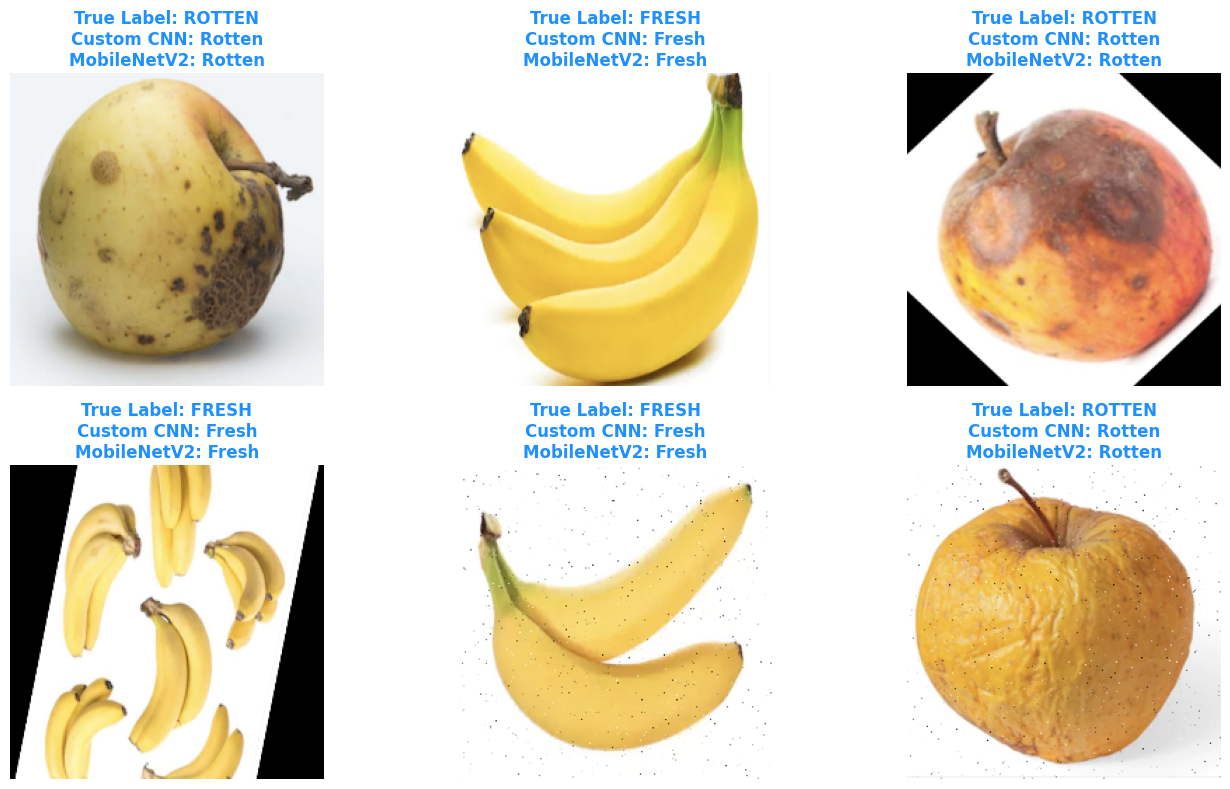

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Fetching unseen test images and asking both models to guess...")

images, labels = next(iter(test_dataset.take(1)))

preds_mobile = model_mobilenet.predict(images, verbose=0)
preds_custom = model_custom.predict(images, verbose=0)

plt.figure(figsize=(14, 8))
plot_limit = min(6, images.shape[0])

for i in range(plot_limit):
    ax = plt.subplot(2, 3, i + 1)

    img_to_show = images[i].numpy().astype("uint8")
    plt.imshow(img_to_show)

    real_index = tf.argmax(labels[i]).numpy()
    actual_label = class_names[real_index]

    mobile_guess = class_names[np.argmax(preds_mobile[i])]
    custom_guess = class_names[np.argmax(preds_custom[i])]

    color = "dodgerblue" if custom_guess == actual_label else "red"

    title_text = f"True Label: {actual_label.upper()}\n"
    title_text += f"Custom CNN: {custom_guess}\n"
    title_text += f"MobileNetV2: {mobile_guess}"

    plt.title(title_text, color=color, fontweight="bold", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [1]:
import os
import tensorflow as tf

model_path = 'fruit_classification_model.h5'

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Could not find {model_path}. Make sure it is in the same folder as this notebook.")

print(f"Loading model from {model_path}...")
model_h5 = tf.keras.models.load_model(model_path, compile=False)
print("H5 model loaded successfully.")
model_h5.summary()

Loading model from fruit_classification_model.h5...
H5 model loaded successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 2)                 │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog
from tensorflow.keras.preprocessing import image

try:
    class_names
except NameError:
    class_names = ["Fresh", "Rotten"]

print("SELECT YOUR FRUIT IMAGES")
print("Choose one or more images from your computer...")

root = Tk()
root.withdraw()
root.attributes("-topmost", True)
selected_files = filedialog.askopenfilenames(
    title="Select fruit images",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp *.webp"),
        ("All files", "*.*"),
    ],
)
root.destroy()

uploaded_files = list(selected_files)
num_images = len(uploaded_files)

if num_images > 0:
    print(f"\nProcessing {num_images} images...")

    rows = (num_images + 2) // 3
    plt.figure(figsize=(12, 4 * rows))

    for i, file_path in enumerate(uploaded_files):
        img = image.load_img(file_path, target_size=(224, 224), color_mode="rgb")
        img_array = image.img_to_array(img)
        img_array_batch = np.expand_dims(img_array, axis=0)

        predictions = model_h5.predict(img_array_batch, verbose=0)
        winning_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        guess_label = class_names[winning_index] if winning_index < len(class_names) else str(winning_index)

        ax = plt.subplot(rows, 3, i + 1)
        plt.imshow(img)

        color = "dodgerblue" if confidence > 80 else "darkorange"
        title_text = f"Guess: {guess_label.upper()}\nConfidence: {confidence:.2f}%"
        plt.title(title_text, color=color, fontweight="bold", fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No images were selected. Run the cell again and choose files.")

SELECT YOUR FRUIT IMAGES
Choose one or more images from your computer...
No images were selected. Run the cell again and choose files.


In [16]:
print("CALCULATING FINAL SCORES ON UNSEEN TESTING DATA...\n")

results_custom = model_custom.evaluate(test_dataset, verbose=0)
results_mobile = model_mobilenet.evaluate(test_dataset, verbose=0)

print(f"Custom CNN Accuracy:  {results_custom[1]*100:.2f}%")
print(f"MobileNetV2 Accuracy: {results_mobile[1]*100:.2f}%")

CALCULATING FINAL SCORES ON UNSEEN TESTING DATA...

Custom CNN Accuracy:  93.04%
MobileNetV2 Accuracy: 97.44%


In [17]:
# Save the best model to an HDF5 file
model_custom.save('fruit_classification_model.h5')

print("Successfully saved as 'fruit_classification_model.h5'")

Successfully saved as 'fruit_classification_model.h5'


--- EXPLAINABILITY: GRAD-CAM HEATMAP ---
This visualizes EXACTLY which pixels the AI looked at to make its decision.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


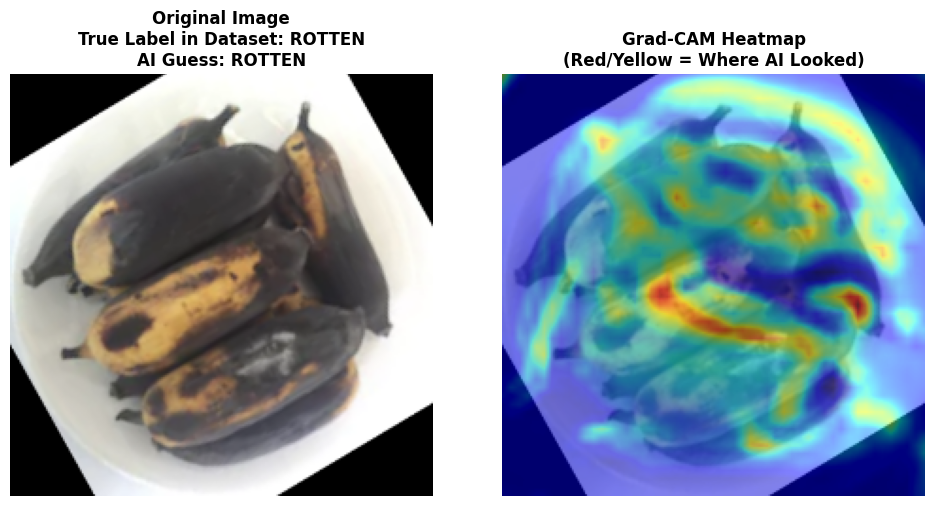

In [19]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("--- EXPLAINABILITY: GRAD-CAM HEATMAP ---")
print("This visualizes EXACTLY which pixels the AI looked at to make its decision.")

# 1. Find the last convolutional layer in our Custom CNN
last_conv_layer = None
for layer in reversed(model_custom.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

if last_conv_layer is None:
    print("Could not find a Conv2D layer for Grad-CAM.")
else:
    # 2. Create a sub-model that outputs both the final predictions AND the internal feature map
    # This approach explicitly traces the input through the model to define outputs within the new graph.
    inputs = model_custom.inputs
    x = inputs
    intermediate_conv_output = None

    # Iterate through the layers of model_custom to build the graph for grad_model
    for layer in model_custom.layers:
        x = layer(x)
        if layer == last_conv_layer:
            intermediate_conv_output = x

    # The final output of the model_custom after passing through all layers
    final_model_output = x

    grad_model = tf.keras.models.Model(
        inputs=inputs,
        outputs=[intermediate_conv_output, final_model_output]
    )

    # 3. Grab one random image from the unseen testing data
    for images, labels in test_dataset.take(1):
        img_array = images[0:1] # Take just the first image in the batch
        true_label = class_names[tf.argmax(labels[0])]
        break

    # 4. Calculate the gradients (the "attention")
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        guess_label = class_names[pred_index]
        loss_val = predictions[:, pred_index]

    # The actual math to generate the heatmap
    grads = tape.gradient(loss_val, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap) # Normalize
    heatmap = heatmap.numpy()

    # 5. Display the Original Image next to the Heatmap
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    original_img = np.squeeze(img_array[0].numpy().astype("uint8"))
    if len(original_img.shape) == 2 or original_img.shape[-1] == 1:
        plt.imshow(original_img, cmap='gray')
    else:
        plt.imshow(original_img)
    plt.title(f"Original Image\nTrue Label in Dataset: {true_label.upper()}\nAI Guess: {guess_label.upper()}", fontweight='bold')
    plt.axis("off")

    # Heatmap Overlay
    plt.subplot(1, 2, 2)
    if len(original_img.shape) == 2 or original_img.shape[-1] == 1:
        plt.imshow(original_img, cmap='gray')
    else:
        plt.imshow(original_img)

    # Resizing the heatmap to match the 224x224 image
    import scipy.ndimage
    heatmap_resized = scipy.ndimage.zoom(heatmap, (224 / heatmap.shape[0], 224 / heatmap.shape[1]), order=1)

    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5) # 'jet' creates the red/blue thermal look
    plt.title("Grad-CAM Heatmap\n(Red/Yellow = Where AI Looked)", fontweight='bold')
    plt.axis("off")

    plt.tight_layout()
    plt.show()